In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

fontsize=16
plt.rc('font', size=fontsize-4)

In [2]:
df = pd.DataFrame(index=['MaxConv2D','FullConv2D','FullConv1D','FullMLP','SlimConv2D','SlimConv1D','SlimMLP'])

In [3]:
df['params'] = [1898,1767,2734,2264,1682,2649,2179]

In [4]:
df['area'] = [635393.79, 619785.84, 300498.47, 348707.10, 606779.20, 288073.16, 335053.16]

In [5]:
df_conv2d = df.loc[['MaxConv2D','FullConv2D','SlimConv2D']]
df_conv1d = df.loc[['FullConv1D','SlimConv1D']]
df_mlp = df.loc[['FullMLP','SlimMLP']]

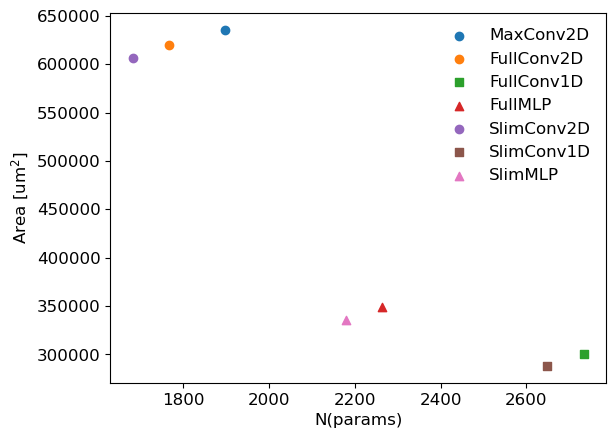

In [6]:
for index, row in df.iterrows():

    if row['area'] > 0:
        if '2D' in index:
            plt.scatter(row['params'],row['area'],label=index,marker='o')
        elif '1D' in index:
            plt.scatter(row['params'],row['area'],label=index,marker='s')
        elif 'MLP' in index:
            plt.scatter(row['params'],row['area'],label=index,marker='^')

plt.ylabel(r'Area [um$^2$]')
plt.xlabel('N(params)')
plt.legend(frameon=False)

In [7]:
with open('dataset3sr/residuals.json') as f:
    residuals = json.load(f)

In [8]:
def fill_df(df, residuals, level, vbl):

    print(residuals['max_2dconv'][level][vbl])
    
    df[vbl] = [residuals['max_2dconv'][level][vbl],
               residuals['full_2dconv'][level][vbl],
               residuals['full_1dconv'][level][vbl],
               residuals['full_mlp'][level][vbl],
               residuals['slim_2dconv'][level][vbl],
               residuals['slim_1dconv'][level][vbl],
               residuals['slim_mlp'][level][vbl]
              ]

    return df

def fill_df_avg(df, residuals, level, vbl1, vbl2, vbl):

    if 'A' in vbl1:
        df[vbl] = [0.5*(residuals['max_2dconv'][level][vbl1] + residuals['max_2dconv'][level][vbl2]),
                   0.5*(residuals['full_2dconv'][level][vbl1] + residuals['full_2dconv'][level][vbl2]),
                   0.5*(residuals['full_1dconv'][level][vbl1] + residuals['full_1dconv'][level][vbl2]),
                   0.5*(residuals['full_mlp'][level][vbl1] + residuals['full_mlp'][level][vbl2]),
                   None,
                   None,
                   None
                  ]
    else: 
        df[vbl] = [0.5*(residuals['max_2dconv'][level][vbl1] + residuals['max_2dconv'][level][vbl2]),
                   0.5*(residuals['full_2dconv'][level][vbl1] + residuals['full_2dconv'][level][vbl2]),
                   0.5*(residuals['full_1dconv'][level][vbl1] + residuals['full_1dconv'][level][vbl2]),
                   0.5*(residuals['full_mlp'][level][vbl1] + residuals['full_mlp'][level][vbl2]),
                   0.5*(residuals['slim_2dconv'][level][vbl1] + residuals['slim_2dconv'][level][vbl2]),
                   0.5*(residuals['slim_1dconv'][level][vbl1] + residuals['slim_1dconv'][level][vbl2]),
                   0.5*(residuals['slim_mlp'][level][vbl1] + residuals['slim_mlp'][level][vbl2])
                  ]

    return df

In [9]:
fill_df_avg(df, residuals, '2-noquant_2t', 'up68_x', 'down68_x', 'sigma68x')
fill_df_avg(df, residuals, '2-noquant_2t', 'up68_y', 'down68_y', 'sigma68y')
fill_df_avg(df, residuals, '2-noquant_2t', 'up68_A', 'down68_A', 'sigma68A')
fill_df_avg(df, residuals, '2-noquant_2t', 'up68_B', 'down68_B', 'sigma68B')

,params,area,sigma68x,sigma68y,sigma68A,sigma68B
MaxConv2D,1898,635393.79,8.154391,2.038537,1.806573,2.422749
FullConv2D,1767,619785.84,7.323143,1.795406,1.556305,2.013714
FullConv1D,2734,300498.47,6.614161,1.639969,1.291464,1.572628
FullMLP,2264,348707.10,6.520416,1.587732,1.235785,1.570610
SlimConv2D,1682,606779.20,6.868642,1.636228,NaN,2.206200
SlimConv1D,2649,288073.16,6.268606,1.521761,NaN,1.789635
SlimMLP,2179,335053.16,6.334235,1.548391,NaN,1.929123


In [10]:
df_conv2d = df.loc[['MaxConv2D','FullConv2D','SlimConv2D']]
df_conv1d = df.loc[['FullConv1D','SlimConv1D']]
df_mlp = df.loc[['FullMLP','SlimMLP']]

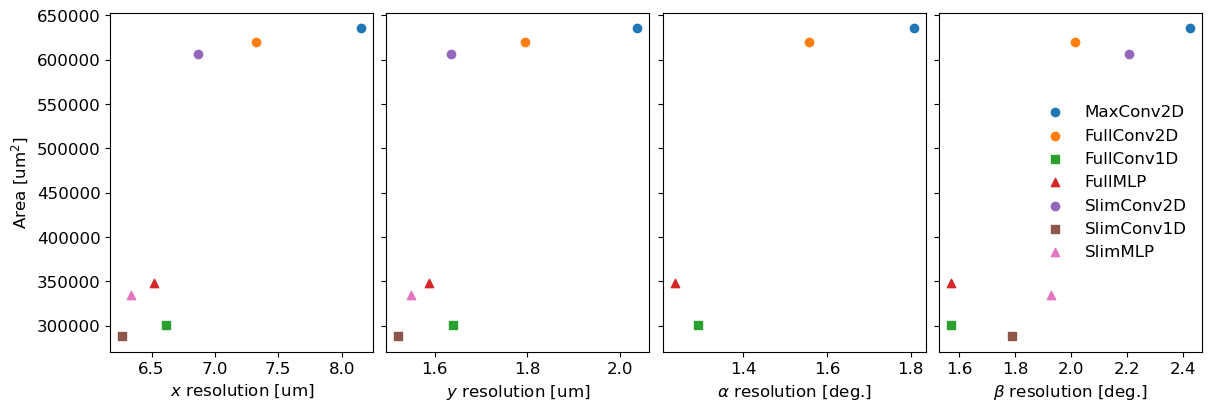

In [11]:
fig, ax = plt.subplots(1,4,figsize=(12,4),sharey=True, constrained_layout=True)
for index, row in df.iterrows():

    if row['area'] > 0:
        if '2D' in index:
            ax[0].scatter(row['sigma68x'],row['area'],label=index,marker='o')
            ax[1].scatter(row['sigma68y'],row['area'],label=index,marker='o')
            ax[2].scatter(row['sigma68A'],row['area'],label=index,marker='o')
            ax[3].scatter(row['sigma68B'],row['area'],label=index,marker='o')
        elif '1D' in index:
            ax[0].scatter(row['sigma68x'],row['area'],label=index,marker='s')
            ax[1].scatter(row['sigma68y'],row['area'],label=index,marker='s')
            ax[2].scatter(row['sigma68A'],row['area'],label=index,marker='s')
            ax[3].scatter(row['sigma68B'],row['area'],label=index,marker='s')
        elif 'MLP' in index:
            ax[0].scatter(row['sigma68x'],row['area'],label=index,marker='^')
            ax[1].scatter(row['sigma68y'],row['area'],label=index,marker='^')
            ax[2].scatter(row['sigma68A'],row['area'],label=index,marker='^')
            ax[3].scatter(row['sigma68B'],row['area'],label=index,marker='^')

ax[0].set_ylabel(r'Area [um$^2$]')
ax[0].set_xlabel(r'$x$ resolution [um]')
ax[1].set_xlabel(r'$y$ resolution [um]')
ax[2].set_xlabel(r'$\alpha$ resolution [deg.]')
ax[3].set_xlabel(r'$\beta$ resolution [deg.]')
ax[3].legend(frameon=False)